# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

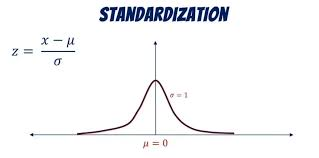


In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv('life expectancy.csv')

numeric_df = df.select_dtypes(include=np.number)

numeric_df = numeric_df.fillna(
    numeric_df.mean()
)

data = numeric_df.values


mean = np.mean(data,axis=0)

std = np.std(data,axis=0)

standardized_data = (
    data-mean
)/std

standardized_data[:5]

array([[-1.64316767e+00, -1.47126042e+00,  3.69556635e+00,
        -2.07755882e-01,  0.00000000e+00,  5.12035488e-16,
         4.88443356e-01,  0.00000000e+00,  0.00000000e+00,
         1.65252541e-01,  2.71388450e-01, -5.44655070e-02],
       [-1.64316767e+00, -2.48370994e+00,  5.65598154e+00,
        -1.87571694e-01, -6.80388025e-01,  5.12035488e-16,
        -6.50550521e-01,  0.00000000e+00,  0.00000000e+00,
         1.41679076e-02,  3.52812867e-01, -1.61274823e-01],
       [-1.64316767e+00,  4.96935316e-01, -5.73561128e-01,
        -2.04442654e-01,  2.80566351e-01, -6.51626995e-01,
         1.78828575e+00,  0.00000000e+00, -5.14011069e-01,
        -2.30399661e-01, -2.46570219e-01, -2.33956066e-01],
       [-1.64316767e+00,  0.00000000e+00, -1.76771417e-16,
        -2.08034193e-01, -1.80221808e-01,  5.12035488e-16,
         1.48659781e-16,  0.00000000e+00, -1.30208306e+00,
        -2.52532310e-01, -2.54175490e-01, -2.51645182e-01],
       [-1.64316767e+00,  5.24958570e-01, -7.8253939

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [3]:
n = standardized_data.shape[0]

cov_matrix = (
1/(n-1)
) * np.dot(
standardized_data.T,
standardized_data
)

cov_matrix

array([[ 1.00030257,  0.19724603, -0.12835215,  0.02272376,  0.09106473,
         0.02366179, -0.04796606, -0.00574351,  0.09223576, -0.00595284,
        -0.03729734,  0.01835281],
       [ 0.19724603,  1.00030257, -0.61389794,  0.1290105 ,  0.27539354,
         0.14391667, -0.05631625,  0.1282821 ,  0.50976471, -0.00601071,
        -0.21745304,  0.04440433],
       [-0.12835215, -0.61389794,  1.00030257, -0.11691888, -0.19454004,
        -0.14510616, -0.03583063, -0.10544222, -0.39730647,  0.01264035,
         0.13929237, -0.03932624],
       [ 0.02272376,  0.1290105 , -0.11691888,  1.00030257,  0.10829423,
        -0.03570881, -0.05855746,  0.00800027,  0.09220225,  0.64827634,
         0.20657229,  0.81921604],
       [ 0.09106473,  0.27539354, -0.19454004,  0.10829423,  1.00030257,
         0.32496542,  0.16462394,  0.0024337 ,  0.18002681, -0.08612462,
        -0.17359482, -0.045258  ],
       [ 0.02366179,  0.14391667, -0.14510616, -0.03570881,  0.32496542,
         1.00030257,  

The covariance matrix is used to understand the relationships between variables and features in a dataset. The use of covariance in PCA is important because the directions with the greatest variance are used to calculate the principal components. It also helps identify correlated or redundant features. Without covariance, it would be difficult to detect patterns in the data and perform effective dimensionality reduction.


### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [4]:
eigenvalues,eigenvectors=np.linalg.eig(
cov_matrix
)

eigenvalues,eigenvectors

(array([3.1085829 , 2.39330878, 1.29166234, 0.01154654, 0.09086916,
        1.07533941, 0.95789002, 0.35358985, 0.84929374, 0.71974427,
        0.55964843, 0.59215543]),
 array([[-1.77529829e-02, -1.81867779e-01,  1.72602692e-01,
          1.17918187e-02,  7.39809093e-04,  8.65621501e-02,
         -9.31362195e-01,  7.56998414e-02, -1.67466987e-01,
          5.63292944e-02, -5.54959474e-02, -1.47379334e-01],
        [-6.88115078e-02, -5.37589222e-01,  1.74239791e-01,
         -1.48466733e-02, -1.52551939e-01, -5.98133170e-02,
          5.77720387e-02, -7.68586168e-01, -1.25942343e-01,
         -5.63549611e-02,  8.85180328e-02,  1.67027081e-01],
        [ 5.57802927e-02,  4.86802172e-01, -1.11254274e-01,
         -1.18999445e-02, -4.16278593e-02,  5.99340048e-02,
         -1.40485046e-01, -5.46918888e-01,  3.29326061e-01,
          2.39282161e-01, -4.64307792e-01, -2.04740001e-01],
        [ 4.10157815e-01, -2.38071348e-01, -2.78185837e-02,
          2.14954524e-01, -5.42684517e-01,  2.0

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [5]:
sorted_indices=np.argsort(
eigenvalues
)[::-1]

sorted_eigenvalues=(
eigenvalues[
sorted_indices
])

sorted_eigenvectors=(
eigenvectors[
:,
sorted_indices
]
)

sorted_eigenvectors


array([[-1.77529829e-02, -1.81867779e-01,  1.72602692e-01,
         8.65621501e-02, -9.31362195e-01, -1.67466987e-01,
         5.63292944e-02, -1.47379334e-01, -5.54959474e-02,
         7.56998414e-02,  7.39809093e-04,  1.17918187e-02],
       [-6.88115078e-02, -5.37589222e-01,  1.74239791e-01,
        -5.98133170e-02,  5.77720387e-02, -1.25942343e-01,
        -5.63549611e-02,  1.67027081e-01,  8.85180328e-02,
        -7.68586168e-01, -1.52551939e-01, -1.48466733e-02],
       [ 5.57802927e-02,  4.86802172e-01, -1.11254274e-01,
         5.99340048e-02, -1.40485046e-01,  3.29326061e-01,
         2.39282161e-01, -2.04740001e-01, -4.64307792e-01,
        -5.46918888e-01, -4.16278593e-02, -1.18999445e-02],
       [ 4.10157815e-01, -2.38071348e-01, -2.78185837e-02,
         2.05105185e-01,  1.13686710e-01,  8.93285232e-02,
         5.15773764e-01, -2.63671943e-01,  1.38738338e-01,
         1.25859475e-01, -5.42684517e-01,  2.14954524e-01],
       [-9.35182336e-02, -3.17424235e-01, -4.2725845

**How Is Explained Variance Used In PCA?**

Explained variance measures how much of the dataset's total variance is captured by each principal component. In PCA, it is used to rank components according to their importance and to determine how many components should be retained. Components with higher explained variance preserve more information from the original dataset. In this analysis, the cumulative explained variance was used to select 8 principal components that retain at least 90% of the total variance.

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [6]:
explained_variance = (
    sorted_eigenvalues /
    np.sum(sorted_eigenvalues)
)

cumulative = np.cumsum(
    explained_variance
)

num_components = np.argmax(
    cumulative >= 0.90
) + 1

principal_components = (
    sorted_eigenvectors[
        :,
        :num_components
    ]
)

reduced_data = np.dot(
    standardized_data,
    principal_components
)

reduced_data[:5]


array([[ 0.39205279,  2.965876  , -1.23552025,  0.24643209,  0.91306113,
         1.30614619,  0.56102422, -0.71375475],
       [ 0.62892145,  4.70857356, -0.70757136, -0.18985274,  0.55038047,
         2.62532308,  1.01368312, -1.46509799],
       [-0.53805778,  0.10004363, -0.97012067,  0.60330712,  1.7308597 ,
        -1.44359482,  0.04342322,  0.77099953],
       [-0.29270261,  0.98583913, -0.51622983, -0.26964711,  1.26527789,
         0.03998135,  0.15935325,  0.61817324],
       [-0.2412367 ,  0.11821729,  1.02678465, -0.94167538,  1.76791497,
         0.07930963, -0.3860377 , -0.22796052]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [7]:
print(
"Reduced Data Shape:",
reduced_data.shape
)

reduced_data[:5]

Reduced Data Shape: (3306, 8)


array([[ 0.39205279,  2.965876  , -1.23552025,  0.24643209,  0.91306113,
         1.30614619,  0.56102422, -0.71375475],
       [ 0.62892145,  4.70857356, -0.70757136, -0.18985274,  0.55038047,
         2.62532308,  1.01368312, -1.46509799],
       [-0.53805778,  0.10004363, -0.97012067,  0.60330712,  1.7308597 ,
        -1.44359482,  0.04342322,  0.77099953],
       [-0.29270261,  0.98583913, -0.51622983, -0.26964711,  1.26527789,
         0.03998135,  0.15935325,  0.61817324],
       [-0.2412367 ,  0.11821729,  1.02678465, -0.94167538,  1.76791497,
         0.07930963, -0.3860377 , -0.22796052]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

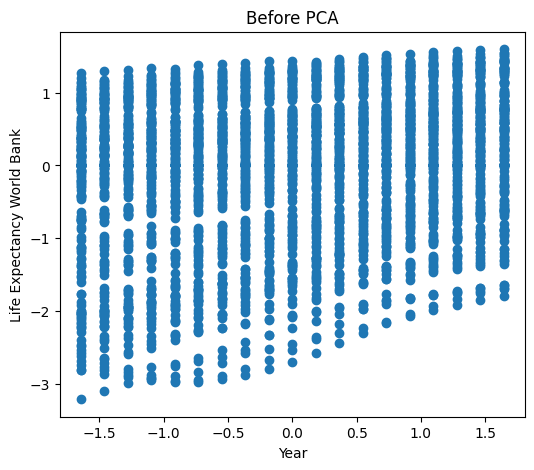

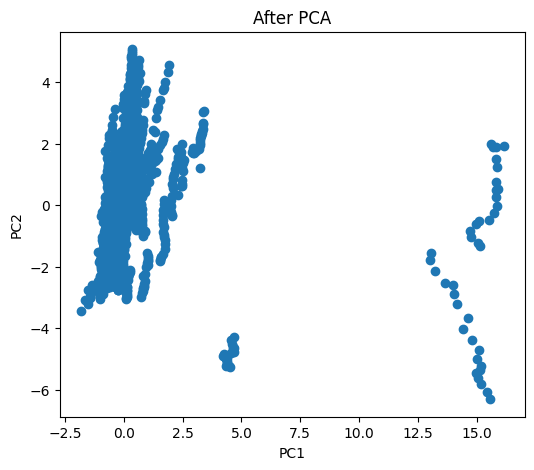

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(
    standardized_data[:, 0],
    standardized_data[:, 1]
)

plt.title("Before PCA")
plt.xlabel(numeric_df.columns[0])
plt.ylabel(numeric_df.columns[1])
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(
    reduced_data[:, 0],
    reduced_data[:, 1]
)

plt.title("After PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**1. Interpretation of the Visual of before and after PCA**

Before PCA, the data appears widely scattered across the original standardized features making patterns difficult to observe. After PCA, the data is projected onto principal components that capture the greatest variance. The transformed plot shows a more organized structure and clearer separation between observations. This indicates that PCA successfully compressed the dataset while preserving its most important information.

**2. Why we selected 8 principle components and what are the tradeoffs?**

Eight principal components were selected because they retain at least 90% of the total variance in the dataset. This reduces the dimensionality from 12 features to 8 while preserving most of the information. The main benefits are reduced computational complexity and lower feature redundancy. The tradeoff is that approximately 10% of the variance is discarded which may contain useful but less significant patterns.

**3. What information is lost when reducing dimensions?**

In this life expectancy dataset, dimensionality reduction may remove subtle information related to economic activity, population pressure, corruption, unemployment, health expenditure, disease prevalence, and Carbon-dioxide emissions. Small country-specific or year-specific variations may also become less apparent. Relationships represented by lower-variance components are lost during the reduction process. However, the most important patterns influencing life expectancy are retained by the selected principal components.